# EY Data Science Challenge — Data Preprocessing

## Objective

The objective of this notebook is to clean and transform the dataset identified during Exploratory Data Analysis (EDA) and prepare it for machine learning.

The preprocessing workflow will cover:

- Standardizing target labels
- Investigating duplicate records and conflicting labels
- Separating input features and target variable
- Handling missing values
- Processing text, numeric, date, and categorical features
- Building a reusable preprocessing pipeline

The original dataset will remain unchanged. All transformations will be applied to a separate working copy or through a fitted preprocessing pipeline.

## 1. Import Libraries

In [269]:
# Import libraries for data preprocessing
# Import the warnings library
import warnings
import pandas as pd
import numpy as np

import os
from pathlib import Path

print("Current directory:", os.getcwd())
print("Project folder exists:", Path(r"D:\EY_Data_Science_Challenge").exists())

# Import tools for building preprocessing pipelines
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

Current directory: d:\EY_Data_Science_Challenge\notebooks
Project folder exists: True


In [270]:
import sys
from pathlib import Path

# Set the project folder
project_dir = Path(r"D:\EY_Data_Science_Challenge")

# Add the project folder to Python's import path
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

# Check whether Python can find the src folder
print("src folder exists:", (project_dir / "src").is_dir())
print("Feature file exists:", (project_dir / "src" / "feature_preparation.py").is_file())

src folder exists: True
Feature file exists: True


In [274]:
import sys
from pathlib import Path
import joblib
import numpy as np

# Add the project directory to the import path
project_dir = Path(r"D:\EY_Data_Science_Challenge")

if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

# Import the class from the Python file
from src.feature_preparation import FeaturePreparation

print("FeaturePreparation imported successfully.")

FeaturePreparation imported successfully.


## 2. Load Dataset

In [199]:
# Load the original dataset
DATA_PATH = r"D:\EY_Data_Science_Challenge\data\raw\Challenge_Data.csv"

df = pd.read_csv(DATA_PATH)

# Create a separate working copy
df_clean = df.copy()

print("Dataset loaded successfully")
print("Dataset shape:", df_clean.shape)

df_clean.head()

Dataset loaded successfully
Dataset shape: (5899, 8)


,Col1,Col2,Col3,Col4,Col5,Col6,Col7,ClassificationLabel
0,Word1 Word2 Word3 Word4 Word5,44912133,"3,575.00",Word771 Word772,8/31/2018,Word560 Word561 Word366 Word562,Doc1,Category_1
1,Word6 Word7,10719,"1,092.50",Word711 Word773 Word774,8/31/2018,Word563 Word366 Word562,NoDoc,Category_2
2,Word8 Word9 Word10 Word11 Word5,4.80Z+11,75,Word775 Word776,10/31/2018,Word563 Word564 Word9 Word26,NoDoc,Category_1
3,Word12 Word13 Word7,10731,"30,980.00",Word777 Word45 Word160 Word45 Word778,01-01-2018,Word565 Word566,NoDoc,Category_1
4,Word8 Word9 Word10 Word11 Word5,4.80F+11,"3,766.80",Word779 Word258 Word780,01-01-2018,Word567 Word568 Word569 Word570,Doc1,Category_1


## 3. Standardize Target Labels

In [200]:
# Check the original target labels and their frequencies
df_clean["ClassificationLabel"].value_counts(dropna=False)

ClassificationLabel
Category_1     5204
Category_2      627
Category4        16
Category_3       12
category_1       11
Categry_6        10
Category 3       10
Category2         4
Category_6        2
Category 5        2
Category _3       1
Name: count, dtype: int64

In [201]:
# Map verified inconsistent labels to standard class names
label_mapping = {
    "category_1": "Category_1",
    "Category2": "Category_2",
    "Category 3": "Category_3",
    "Category _3": "Category_3",
    "Category4": "Category_4",
    "Category 5": "Category_5",
    "Categry_6": "Category_6"
}

df_clean["ClassificationLabel"] = (
    df_clean["ClassificationLabel"].replace(label_mapping)
)

# Check the cleaned target distribution
df_clean["ClassificationLabel"].value_counts(dropna=False)

ClassificationLabel
Category_1    5215
Category_2     631
Category_3      23
Category_4      16
Category_6      12
Category_5       2
Name: count, dtype: int64

## 4. Duplicate and Conflicting Label Analysis


In [202]:
# Define the seven input features
input_cols = [
    "Col1", "Col2", "Col3", "Col4",
    "Col5", "Col6", "Col7"
]

# Count exact duplicate records
print("Exact duplicate rows:", df_clean.duplicated().sum())

Exact duplicate rows: 679


In [203]:
# Find identical input combinations with different target labels
label_conflicts = (
    df_clean.groupby(input_cols, dropna=False)["ClassificationLabel"]
    .nunique()
    .reset_index(name="Number_of_Labels")
)

label_conflicts = label_conflicts[
    label_conflicts["Number_of_Labels"] > 1
]

print("Conflicting input groups:", len(label_conflicts))

display(label_conflicts)

Conflicting input groups: 1


,Col1,Col2,Col3,Col4,Col5,Col6,Col7,Number_of_Labels
3695,Word42 Word43 Word5,8229,"1,510.00",Word562,7/31/2018,Word563 Word580 Word581 Word232,NoDoc,2


## 5. Separate Features and Target

In [204]:
# Create the input feature matrix and target variable
X = df_clean[input_cols].copy()
y = df_clean["ClassificationLabel"].copy()

print("Input shape:", X.shape)
print("Target shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

Input shape: (5899, 7)
Target shape: (5899,)

Class distribution:
ClassificationLabel
Category_1    5215
Category_2     631
Category_3      23
Category_4      16
Category_6      12
Category_5       2
Name: count, dtype: int64


## 6. Train and Holdout Split

Reserve 10% of the dataset for final evaluation. The holdout data must not be used to fit preprocessing transformations or tune the model.
The target distribution contains rare classes, so the splitting strategy must be selected with these class counts in mind.

In [205]:
# Check class counts before splitting
print(y.value_counts())
print("\nSmallest class size:", y.value_counts().min())

ClassificationLabel
Category_1    5215
Category_2     631
Category_3      23
Category_4      16
Category_6      12
Category_5       2
Name: count, dtype: int64

Smallest class size: 2


## 7. Convert Col3 to Numeric
Col3 contains numerical values stored as strings, including values with commas as thousands separators. 
Remove the commas and convert the column to a numeric data type so it can be used as a numerical feature in the machine-learning model.

In [206]:
# Remove commas and convert Col3 to numeric
df_clean["Col3"] = pd.to_numeric(df_clean["Col3"].str.replace(",", "", regex=False),errors="coerce")

# Check the resulting data type
print("Col3 data type:", df_clean["Col3"].dtype)

# Check for missing values after conversion
print("Missing values in Col3:", df_clean["Col3"].isna().sum())

# Display a few converted values
df_clean["Col3"].head()

Col3 data type: float64
Missing values in Col3: 0


0     3575.0
1     1092.5
2       75.0
3    30980.0
4     3766.8
Name: Col3, dtype: float64

## 8. Convert Col5 to DateTime
Col5 contains dates stored as strings in different formats. 
Convert these values into a consistent datetime format so that date-related features can be explored.


In [207]:
# Convert Col5 to datetime format
df_clean["Col5"] = pd.to_datetime(df_clean["Col5"],errors="coerce",format="mixed")

# Check the resulting data type
print("Col5 data type:", df_clean["Col5"].dtype)

# Check for missing values after conversion
print("Missing values in Col5:", df_clean["Col5"].isna().sum())

# Check the date range
print("Minimum date:", df_clean["Col5"].min())
print("Maximum date:", df_clean["Col5"].max())

# Display a few converted values
df_clean["Col5"].head()

Col5 data type: datetime64[us]
Missing values in Col5: 0
Minimum date: 2016-10-01 00:00:00
Maximum date: 2018-12-31 00:00:00


0   2018-08-31
1   2018-08-31
2   2018-10-31
3   2018-01-01
4   2018-01-01
Name: Col5, dtype: datetime64[us]

## 9. Handle Missing Values in Col4

Col4 contains text entries and missing values. 
Create a missing-value indicator before filling the missing entries so that the original missingness information is preserved.
Replace missing text values with empty strings to prepare the column for text vectorization in the next steps.

In [208]:
# Check missing values before handling them
print("Missing values before:", df_clean["Col4"].isna().sum())

# Create an indicator for originally missing or empty values
df_clean["Col4_Missing"] = (
    df_clean["Col4"].isna() |
    df_clean["Col4"].eq("")
).astype(int)

# Replace missing text values with empty strings
df_clean["Col4"] = df_clean["Col4"].fillna("")

# Check the results
print("Missing values after:", df_clean["Col4"].isna().sum())
print("Missing-value indicator count:", df_clean["Col4_Missing"].sum())

Missing values before: 153
Missing values after: 0
Missing-value indicator count: 153


## 10. Prepare Text Features
Col1, Col4, and Col6 contain text entries. Text data must be converted into numerical features before it can be used by a machine-learning model.
We will inspect these columns and prepare them for TF-IDF vectorization, which represents text using numerical weights based on the importance of individual terms.

In [209]:
# Define the text columns
text_cols = ["Col1", "Col4", "Col6"]

# Check sample values and missing values
for col in text_cols:
    print(f"\nColumn: {col}")
    print("Missing values:", df_clean[col].isna().sum())
    print(df_clean[col].head(5).tolist())


Column: Col1
Missing values: 0
['Word1 Word2 Word3 Word4 Word5', 'Word6 Word7', 'Word8 Word9 Word10 Word11 Word5', 'Word12 Word13 Word7', 'Word8 Word9 Word10 Word11 Word5']

Column: Col4
Missing values: 0
['Word771 Word772', 'Word711 Word773 Word774', 'Word775 Word776', 'Word777 Word45 Word160 Word45 Word778', 'Word779 Word258 Word780']

Column: Col6
Missing values: 0
['Word560 Word561 Word366 Word562', 'Word563 Word366 Word562', 'Word563 Word564 Word9 Word26', 'Word565 Word566', 'Word567 Word568 Word569 Word570']


In [210]:
# Count empty text entries in each text column
for col in text_cols:
    empty_count = df_clean[col].eq("").sum()
    print(f"{col} empty strings: {empty_count}")

Col1 empty strings: 0
Col4 empty strings: 153
Col6 empty strings: 0


## 11. Inspect Col2 and Create Structural Features

Col2 contains code-like values with different formats. Since these values may represent identifiers rather than numerical quantities, converting the entire column to numeric could lose useful information.

We will inspect the values and create basic structural features for comparison during model evaluation.

In [211]:
# Inspect some values from Col2
print("Sample Col2 values:")
display(df_clean["Col2"].head(10))

# Check the number of unique values
print("Unique values:", df_clean["Col2"].nunique())

# Check for missing values
print("Missing values:", df_clean["Col2"].isna().sum())

Sample Col2 values:


0            44912133
1               10719
2            4.80Z+11
3               10731
4            4.80F+11
5    KBNZGNNWMA072618
6              WE1243
7               20136
8                4411
9            4.80F+11
Name: Col2, dtype: str

Unique values: 4818
Missing values: 0


In [212]:
# Convert Col2 to string for consistent feature extraction
col2_text = df_clean["Col2"].fillna("").astype(str)

# Create basic features based on the code format
df_clean["Col2_Length"] = col2_text.str.len()
df_clean["Col2_Has_Letter"] = col2_text.str.contains(r"[A-Za-z]", regex=True).astype(int)
df_clean["Col2_Has_Dash"] = col2_text.str.contains("-", regex=False).astype(int)

# Display the original and engineered features
display(df_clean[["Col2", "Col2_Length", "Col2_Has_Letter", "Col2_Has_Dash"]].head(10))

,Col2,Col2_Length,Col2_Has_Letter,Col2_Has_Dash
0,44912133,8,0,0
1,10719,5,0,0
2,4.80Z+11,8,1,0
3,10731,5,0,0
4,4.80F+11,8,1,0
5,KBNZGNNWMA072618,16,1,0
6,WE1243,6,1,0
7,20136,5,0,0
8,4411,4,0,0
9,4.80F+11,8,1,0


## 12. Inspect Categorical Feature Col7

Col7 contains a small number of categorical values, such as Doc1, Doc2, Doc3, and NoDoc. These values represent categories rather than numerical measurements.

We will inspect the category distribution and prepare this feature for encoding during model training.

In [213]:
# Check the categories and their frequencies
print("Unique categories:", df_clean["Col7"].nunique())
print("\nCategory distribution:")
print(df_clean["Col7"].value_counts(dropna=False))

Unique categories: 4

Category distribution:
Col7
NoDoc    4635
Doc1     1108
Doc3      121
Doc2       35
Name: count, dtype: int64


## 13. Prepare Features for the Preprocessing Pipeline

Review the original input features and engineered features created during preprocessing. Keep the target variable separate from the input features to prevent target leakage.

The final feature set and transformations will be incorporated into a reusable scikit-learn pipeline.

In [214]:
# Check the columns currently available
print("Columns in the working dataset:")
print(df_clean.columns.tolist())

# Check the target distribution
print("\nTarget distribution:")
print(df_clean["ClassificationLabel"].value_counts())

Columns in the working dataset:
['Col1', 'Col2', 'Col3', 'Col4', 'Col5', 'Col6', 'Col7', 'ClassificationLabel', 'Col4_Missing', 'Col2_Length', 'Col2_Has_Letter', 'Col2_Has_Dash']

Target distribution:
ClassificationLabel
Category_1    5215
Category_2     631
Category_3      23
Category_4      16
Category_6      12
Category_5       2
Name: count, dtype: int64


## 14. Train and Holdout Split

Separate the dataset into training and final holdout sets. Reserve 10% of the records for final model evaluation, as required by the challenge.

The holdout set must remain untouched during preprocessing decisions, model selection, and hyperparameter tuning. Since some classes have very few records, the class distribution must be reviewed before choosing the splitting strategy.

In [215]:
# Separate the input features and target
input_cols = ["Col1", "Col2", "Col3", "Col4", "Col5", "Col6", "Col7"]

X = df_clean[input_cols].copy()
y = df_clean["ClassificationLabel"].copy()

# Check the number of records in each class
print("Class distribution:")
print(y.value_counts())

print("\nTotal records:", len(y))
print("10% holdout size:", round(len(y) * 0.10))

Class distribution:
ClassificationLabel
Category_1    5215
Category_2     631
Category_3      23
Category_4      16
Category_6      12
Category_5       2
Name: count, dtype: int64

Total records: 5899
10% holdout size: 590


In [216]:
# Identify classes with fewer than 10 records
rare_classes = y.value_counts()[y.value_counts() < 10]

print("Classes with fewer than 10 records:")
print(rare_classes)

Classes with fewer than 10 records:
ClassificationLabel
Category_5    2
Name: count, dtype: int64


### 15. Check Duplicate Input Combinations

Before splitting the dataset, check how many input combinations appear more than once. This helps identify potential overlap between training and holdout data.
Conflicting target labels must be reviewed separately before the final split is created.

In [217]:
# Count repeated combinations of the seven input features
input_cols = ["Col1", "Col2", "Col3", "Col4", "Col5", "Col6", "Col7"]

duplicate_input_mask = df_clean.duplicated(
    subset=input_cols,
    keep=False
)

print("Rows with repeated input combinations:", duplicate_input_mask.sum())

# Check the number of unique input combinations
print(
    "Unique input combinations:",
    df_clean[input_cols].drop_duplicates().shape[0]
)

Rows with repeated input combinations: 1215
Unique input combinations: 5219


In [218]:
# Find input combinations associated with multiple target labels
label_conflicts = (
    df_clean.groupby(input_cols, dropna=False)["ClassificationLabel"]
    .nunique()
    .reset_index(name="Number_of_Labels")
)

label_conflicts = label_conflicts[
    label_conflicts["Number_of_Labels"] > 1
]

print("Conflicting input groups:", len(label_conflicts))
display(label_conflicts)

Conflicting input groups: 1


,Col1,Col2,Col3,Col4,Col5,Col6,Col7,Number_of_Labels
3695,Word42 Word43 Word5,8229,1510.0,Word562,2018-07-31,Word563 Word580 Word581 Word232,NoDoc,2


### 15.1 Review Conflicting Target Labels

One input combination is associated with more than one target label. Inspect the original records to identify the conflicting labels before deciding how to handle this group.

In [219]:
# Display all records belonging to the conflicting input group
conflicting_rows = df_clean.merge(
    label_conflicts[input_cols],
    on=input_cols,
    how="inner"
)

display(
    conflicting_rows[
        input_cols + ["ClassificationLabel"]
    ]
)

,Col1,Col2,Col3,Col4,Col5,Col6,Col7,ClassificationLabel
0,Word42 Word43 Word5,8229,1510.0,Word562,2018-07-31,Word563 Word580 Word581 Word232,NoDoc,Category_1
1,Word42 Word43 Word5,8229,1510.0,Word562,2018-07-31,Word563 Word580 Word581 Word232,NoDoc,Category_1
2,Word42 Word43 Word5,8229,1510.0,Word562,2018-07-31,Word563 Word580 Word581 Word232,NoDoc,Category_1
3,Word42 Word43 Word5,8229,1510.0,Word562,2018-07-31,Word563 Word580 Word581 Word232,NoDoc,Category_2
4,Word42 Word43 Word5,8229,1510.0,Word562,2018-07-31,Word563 Word580 Word581 Word232,NoDoc,Category_2


In [220]:
# Show the target labels for the conflicting records
print(conflicting_rows["ClassificationLabel"].value_counts())

ClassificationLabel
Category_1    3
Category_2    2
Name: count, dtype: int64


### 16. Handle Conflicting Target Labels

One group of identical input features was associated with two different target labels: Category_1 (3 records) and Category_2 (2 records).

Since the available input features cannot explain the difference, these five ambiguous records will be excluded from model development.

The original dataset will remain unchanged. Exact duplicates with consistent labels will be retained for now and handled through a group-aware splitting strategy to avoid train-test leakage.

In [221]:
# Identify all rows belonging to conflicting input groups
conflicting_index = df_clean.merge( label_conflicts[input_cols],on=input_cols,how="inner").index

# Use a merge indicator to identify conflicting rows safely
conflict_check = df_clean.merge(label_conflicts[input_cols],on=input_cols,how="left",indicator=True)

# Keep only records without conflicting labels
df_model = df_clean.loc[conflict_check["_merge"].eq("left_only").to_numpy()].copy()

print("Original records:", len(df_clean))
print("Records removed:", len(df_clean) - len(df_model))
print("Remaining records:", len(df_model))

Original records: 5899
Records removed: 5
Remaining records: 5894


In [222]:
# Confirm that no conflicting input groups remain
remaining_conflicts = (df_model.groupby(input_cols, dropna=False)["ClassificationLabel"].nunique())

print("Remaining conflicting groups:",
      (remaining_conflicts > 1).sum())

print("Remaining exact duplicates:",
      df_model.duplicated().sum())

Remaining conflicting groups: 0
Remaining exact duplicates: 676


## 17. Split Data into Training and Holdout Sets

Reserve approximately 10% of the data for final evaluation. Identical input combinations will be assigned to the same split to prevent duplicate-input leakage.
The holdout set will remain untouched during model selection and preprocessing fitting. Because the dataset contains rare classes, class counts will be checked after splitting.

In [223]:
# Import the group-aware splitter
# Import the group-aware splitting method
from sklearn.model_selection import GroupShuffleSplit

# Separate input features and target label
X = df_model[input_cols].copy()
y = df_model["ClassificationLabel"].copy()

# Group records with identical input combinations
groups = (
    df_model[input_cols]
    .fillna("<MISSING>")
    .astype(str)
    .agg(" | ".join, axis=1)
)

# Create a group-aware 90/10 split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.10,
    random_state=42
)

train_idx, holdout_idx = next(
    splitter.split(X, y, groups=groups)
)

# Create training and holdout sets
X_train = X.iloc[train_idx].copy()
X_holdout = X.iloc[holdout_idx].copy()

y_train = y.iloc[train_idx].copy()
y_holdout = y.iloc[holdout_idx].copy()

# Display split information
print("Total records:", len(X))
print("Training records:", len(X_train))
print("Holdout records:", len(X_holdout))
print(
    "Holdout percentage:",
    round(len(X_holdout) / len(X) * 100, 2), "%"
)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nHoldout class distribution:")
print(y_holdout.value_counts())

Total records: 5894
Training records: 5284
Holdout records: 610
Holdout percentage: 10.35 %

Training class distribution:
ClassificationLabel
Category_1    4675
Category_2     563
Category_3      22
Category_4      14
Category_6       8
Category_5       2
Name: count, dtype: int64

Holdout class distribution:
ClassificationLabel
Category_1    537
Category_2     66
Category_6      4
Category_4      2
Category_3      1
Name: count, dtype: int64


In [224]:
# Compare class distributions in the training and holdout sets
print("Training class distribution:")
print(y_train.value_counts())

print("\nHoldout class distribution:")
print(y_holdout.value_counts())

Training class distribution:
ClassificationLabel
Category_1    4675
Category_2     563
Category_3      22
Category_4      14
Category_6       8
Category_5       2
Name: count, dtype: int64

Holdout class distribution:
ClassificationLabel
Category_1    537
Category_2     66
Category_6      4
Category_4      2
Category_3      1
Name: count, dtype: int64


In [225]:
# Confirm that identical input combinations do not cross the split
train_groups = set(groups.iloc[train_idx])
holdout_groups = set(groups.iloc[holdout_idx])

print("Overlapping input groups:", len(train_groups & holdout_groups))

Overlapping input groups: 0


In [226]:
# Import Path to manage folder and file paths
from pathlib import Path

# Create the processed data folder if it doesn't exist
processed_dir = Path(r"D:\EY_Data_Science_Challenge\data\processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Verify the train and holdout split
print("Total modeling records:", len(X))
print("Training records:", len(X_train))
print("Holdout records:", len(X_holdout))
print("Holdout percentage:", round(len(X_holdout) / len(X) * 100, 2), "%")

# Check for overlapping input groups
print("Overlapping input groups:", len(train_groups & holdout_groups))

# Create a DataFrame to record the split assignment
split_indices = pd.DataFrame({
    "row_index": df_model.index,
    "split": [
        "train" if i in train_idx else "holdout"
        for i in range(len(df_model))
    ]
})

# Save the split indices
split_path = processed_dir / "split_indices.csv"
split_indices.to_csv(split_path, index=False)

print("\nSplit indices saved successfully.")
print("Saved location:", split_path)

Total modeling records: 5894
Training records: 5284
Holdout records: 610
Holdout percentage: 10.35 %
Overlapping input groups: 0

Split indices saved successfully.
Saved location: D:\EY_Data_Science_Challenge\data\processed\split_indices.csv


In [227]:
# Check the data types in the original input features
print("Feature data types:")
print(X_train.dtypes)

# Check the training feature columns
print("\nTraining columns:")
print(X_train.columns.tolist())

Feature data types:
Col1               str
Col2               str
Col3           float64
Col4               str
Col5    datetime64[us]
Col6               str
Col7               str
dtype: object

Training columns:
['Col1', 'Col2', 'Col3', 'Col4', 'Col5', 'Col6', 'Col7']


## 18. Build the Preprocessing Pipeline

Create a reusable preprocessing pipeline for all seven input features.

- Text columns will be transformed using TF-IDF.
- Col3 will be imputed and scaled as a numerical feature.
- Col5 will be converted into year and month features.
- Col2 will initially be represented using structural features.
- Col7 will be one-hot encoded.
- Col4 missingness will be preserved through a missing-value indicator.

The pipeline will be fitted using training data only to avoid data leakage. The same transformations will be reused for holdout evaluation and future predictions.

In [228]:
# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Import a transformer for custom feature extraction
from sklearn.preprocessing import FunctionTransformer

In [229]:
# Prepare features before applying individual transformations
def prepare_features(data):
    data = data.copy()

    # Convert Col2 into structural features
    col2_text = data["Col2"].fillna("").astype(str)

    data["Col2_Length"] = col2_text.str.len()
    data["Col2_Has_Letter"] = (
        col2_text.str.contains(r"[A-Za-z]", regex=True).astype(int)
    )
    data["Col2_Has_Dash"] = (
        col2_text.str.contains("-", regex=False).astype(int)
    )

    # Preserve missingness in Col4
    data["Col4_Missing"] = (
        data["Col4"].isna() | data["Col4"].eq("")
    ).astype(int)

    # Fill missing text values
    for col in ["Col1", "Col4", "Col6"]:
        data[col] = data[col].fillna("").astype(str)

    # Extract date features from Col5
    dates = pd.to_datetime(data["Col5"], errors="coerce", format="mixed")
    data["Col5_Year"] = dates.dt.year
    data["Col5_Month"] = dates.dt.month

    return data

In [230]:
# Check the prepared training features
X_train_prepared = prepare_features(X_train)

print("Prepared feature shape:", X_train_prepared.shape)
print("Prepared columns:")
print(X_train_prepared.columns.tolist())

display(X_train_prepared.head())

Prepared feature shape: (5284, 13)
Prepared columns:
['Col1', 'Col2', 'Col3', 'Col4', 'Col5', 'Col6', 'Col7', 'Col2_Length', 'Col2_Has_Letter', 'Col2_Has_Dash', 'Col4_Missing', 'Col5_Year', 'Col5_Month']


,Col1,Col2,Col3,Col4,Col5,Col6,Col7,Col2_Length,Col2_Has_Letter,Col2_Has_Dash,Col4_Missing,Col5_Year,Col5_Month
0,Word1 Word2 Word3 Word4 Word5,44912133,3575.00,Word771 Word772,2018-08-31,Word560 Word561 Word366 Word562,Doc1,8,0,0,0,2018,8
2,Word8 Word9 Word10 Word11 Word5,4.80Z+11,75.00,Word775 Word776,2018-10-31,Word563 Word564 Word9 Word26,NoDoc,8,1,0,0,2018,10
3,Word12 Word13 Word7,10731,30980.00,Word777 Word45 Word160 Word45 Word778,2018-01-01,Word565 Word566,NoDoc,5,0,0,0,2018,1
4,Word8 Word9 Word10 Word11 Word5,4.80F+11,3766.80,Word779 Word258 Word780,2018-01-01,Word567 Word568 Word569 Word570,Doc1,8,1,0,0,2018,1
5,Word14 Word15,KBNZGNNWMA072618,1898.83,Word613 Word781 Word782,2018-08-31,Word571 Word52 Word572 Word573 Word574,NoDoc,16,1,0,0,2018,8


### 19 Define Feature Transformations

Define separate transformations for text, numeric, and categorical features.

- Text columns (`Col1`, `Col4`, and `Col6`) will use TF-IDF.
- Numeric columns (`Col3`, `Col2_Length`, `Col2_Has_Letter`, `Col2_Has_Dash`, `Col4_Missing`, `Col5_Year`, and `Col5_Month`) will use imputation and scaling.
- `Col7` will use one-hot encoding.
- The original `Col2` code will initially be excluded from this baseline representation and can be evaluated separately during model comparison.

The transformations will be fitted on the training data only.

In [231]:
# Define the text columns
text_cols = ["Col1", "Col4", "Col6"]

# Define the numerical columns
numeric_cols = [
    "Col3",
    "Col2_Length",
    "Col2_Has_Letter",
    "Col2_Has_Dash",
    "Col4_Missing",
    "Col5_Year",
    "Col5_Month"
]

# Define the categorical columns
categorical_cols = ["Col7"]

# Preprocess numerical features
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocess categorical features
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine the transformations
preprocessor = ColumnTransformer([
    ("text1", TfidfVectorizer(), "Col1"),
    ("text4", TfidfVectorizer(), "Col4"),
    ("text6", TfidfVectorizer(), "Col6"),
    ("numeric", numeric_pipeline, numeric_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])

In [232]:
# Prepare features consistently for both datasets
X_train_prepared = prepare_features(X_train)
X_holdout_prepared = prepare_features(X_holdout)

print("Training shape:", X_train_prepared.shape)
print("Holdout shape:", X_holdout_prepared.shape)

Training shape: (5284, 13)
Holdout shape: (610, 13)


In [233]:
# Fit transformations on training data and transform it
X_train_transformed = preprocessor.fit_transform(X_train_prepared)

# Transform holdout data without refitting
X_holdout_transformed = preprocessor.transform(X_holdout_prepared)

print("Transformed training shape:", X_train_transformed.shape)
print("Transformed holdout shape:", X_holdout_transformed.shape)

Transformed training shape: (5284, 2294)
Transformed holdout shape: (610, 2294)


## 20. Validate Preprocessed Data

Validate the transformed training and holdout datasets before model training. Confirm that both datasets have the same feature dimensions and that the transformation has not introduced invalid numerical values.

The fitted preprocessing pipeline will be reused during model evaluation and prediction.

In [234]:
# Check the dimensions of the transformed datasets
print("Training shape:", X_train_transformed.shape)
print("Holdout shape:", X_holdout_transformed.shape)

# Check whether both datasets have the same number of features
print(
    "Same number of features:",
    X_train_transformed.shape[1] == X_holdout_transformed.shape[1]
)

# Check for invalid numerical values
import numpy as np

print(
    "Training contains invalid values:",
    not np.isfinite(X_train_transformed.data).all()
    if hasattr(X_train_transformed, "data")
    else not np.isfinite(X_train_transformed).all()
)

print(
    "Holdout contains invalid values:",
    not np.isfinite(X_holdout_transformed.data).all()
    if hasattr(X_holdout_transformed, "data")
    else not np.isfinite(X_holdout_transformed).all()
)

Training shape: (5284, 2294)
Holdout shape: (610, 2294)
Same number of features: True
Training contains invalid values: False
Holdout contains invalid values: False


## 21. Prepare Target Labels
Prepare the target labels for model training and verify that the training and holdout targets align with their respective feature matrices.
The classes are imbalanced, so model evaluation will include macro F1, balanced accuracy, and per-class precision and recall.

In [235]:
# Check that the target labels match the feature rows
print("Training features:", X_train_transformed.shape[0])
print("Training labels:", len(y_train))

print("Holdout features:", X_holdout_transformed.shape[0])
print("Holdout labels:", len(y_holdout))

# Check the number of target classes
print("\nNumber of classes:", y_train.nunique())

print("\nTraining target distribution:")
print(y_train.value_counts())

Training features: 5284
Training labels: 5284
Holdout features: 610
Holdout labels: 610

Number of classes: 6

Training target distribution:
ClassificationLabel
Category_1    4675
Category_2     563
Category_3      22
Category_4      14
Category_6       8
Category_5       2
Name: count, dtype: int64


## 22. Train a Baseline Model

Train a Logistic Regression classifier using the preprocessed training data. Use balanced class weights to reduce the influence of the majority class.

The holdout set will not be used for fitting the model or selecting hyperparameters. It will be reserved for final evaluation.

In [236]:
# Import the baseline classification model
from sklearn.linear_model import LogisticRegression

# Create the baseline model
baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

# Train the model using only the training data
baseline_model.fit(X_train_transformed, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


## 23. Evaluate the Baseline Model

Evaluate the baseline Logistic Regression model using the holdout dataset. Since the target classes are highly imbalanced, use macro F1-score, balanced accuracy, and per-class precision and recall alongside overall accuracy.

The holdout set will be used only for evaluation, not for fitting the model.

In [237]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predict the holdout labels
y_pred = baseline_model.predict(X_holdout_transformed)

# Calculate evaluation metrics
accuracy = accuracy_score(y_holdout, y_pred)
balanced_acc = balanced_accuracy_score(y_holdout, y_pred)
macro_f1 = f1_score(
    y_holdout,
    y_pred,
    average="macro",
    zero_division=0
)

print("Baseline Model Results")
print("----------------------")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Macro F1-score:    {macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_holdout,
    y_pred,
    zero_division=0
))

Baseline Model Results
----------------------
Accuracy:          0.9410
Balanced Accuracy: 0.8767
Macro F1-score:    0.7039

Classification Report:
              precision    recall  f1-score   support

  Category_1       0.99      0.94      0.97       537
  Category_2       0.68      0.94      0.79        66
  Category_3       1.00      1.00      1.00         1
  Category_4       0.67      1.00      0.80         2
  Category_5       0.00      0.00      0.00         0
  Category_6       1.00      0.50      0.67         4

    accuracy                           0.94       610
   macro avg       0.72      0.73      0.70       610
weighted avg       0.96      0.94      0.95       610



d:\EY_Data_Science_Challenge\venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 24. Evaluate All Target Classes

Generate the classification report using the complete set of target classes. This ensures that classes missing from the holdout are still displayed, with their evaluation limitations made explicit.

In [238]:
# Include every class known to the trained model
all_classes = baseline_model.classes_

print(classification_report(
    y_holdout,
    y_pred,
    labels=all_classes,
    zero_division=0
))

              precision    recall  f1-score   support

  Category_1       0.99      0.94      0.97       537
  Category_2       0.68      0.94      0.79        66
  Category_3       1.00      1.00      1.00         1
  Category_4       0.67      1.00      0.80         2
  Category_5       0.00      0.00      0.00         0
  Category_6       1.00      0.50      0.67         4

    accuracy                           0.94       610
   macro avg       0.72      0.73      0.70       610
weighted avg       0.96      0.94      0.95       610



## 25. Save Baseline metrics

In [239]:
# Store the baseline evaluation metrics
baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Balanced Accuracy": balanced_acc,
    "Macro F1": macro_f1
}

baseline_results_df = pd.DataFrame([baseline_results])
display(baseline_results_df)

,Model,Accuracy,Balanced Accuracy,Macro F1
0,Logistic Regression,0.940984,0.876706,0.703852


## 26. Train a Linear SVM Model

Train a Linear Support Vector Machine (SVM) using the preprocessed training data. 
Linear SVM is suitable for sparse, high-dimensional text features and provides a useful comparison with Logistic Regression.

Evaluate the model using the same holdout data and metrics to ensure a fair comparison.

In [240]:
# Import the Linear SVM model
from sklearn.svm import LinearSVC

# Create the model
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

# Train the model using training data only
svm_model.fit(X_train_transformed, y_train)

print("Linear SVM trained successfully.")

Linear SVM trained successfully.


In [241]:
# Predict the holdout labels
svm_pred = svm_model.predict(X_holdout_transformed)

# Calculate evaluation metrics
svm_accuracy = accuracy_score(y_holdout, svm_pred)

svm_balanced_accuracy = balanced_accuracy_score(
    y_holdout, svm_pred
)

svm_macro_f1 = f1_score(
    y_holdout,
    svm_pred,
    average="macro",
    zero_division=0
)

print("Linear SVM Results")
print("------------------")
print(f"Accuracy:          {svm_accuracy:.4f}")
print(f"Balanced Accuracy: {svm_balanced_accuracy:.4f}")
print(f"Macro F1-score:    {svm_macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_holdout,
    svm_pred,
    labels=baseline_model.classes_,
    zero_division=0
))

Linear SVM Results
------------------
Accuracy:          0.9557
Balanced Accuracy: 0.7202
Macro F1-score:    0.7752

Classification Report:
              precision    recall  f1-score   support

  Category_1       0.98      0.97      0.97       537
  Category_2       0.79      0.88      0.83        66
  Category_3       1.00      1.00      1.00         1
  Category_4       1.00      0.50      0.67         2
  Category_5       0.00      0.00      0.00         0
  Category_6       1.00      0.25      0.40         4

    accuracy                           0.96       610
   macro avg       0.80      0.60      0.65       610
weighted avg       0.96      0.96      0.95       610



In [242]:
# Compare the baseline and Linear SVM
model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "Macro F1": macro_f1
    },
    {
        "Model": "Linear SVM",
        "Accuracy": svm_accuracy,
        "Balanced Accuracy": svm_balanced_accuracy,
        "Macro F1": svm_macro_f1
    }
])

display(
    model_comparison.sort_values(
        by="Macro F1",
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Balanced Accuracy,Macro F1
0,Linear SVM,0.955738,0.720171,0.775198
1,Logistic Regression,0.940984,0.876706,0.703852


## 27. Compare Per-Class Model Performance

Compare the classification reports and confusion matrices for Logistic Regression and Linear SVM. 
This will help identify which classes each model predicts well and where misclassifications occur.

The final model should balance overall performance with reliable detection of minority classes.

In [243]:
# Compare precision, recall, and F1-score for each class
print("Logistic Regression Report")
print(classification_report(
    y_holdout,
    y_pred,
    labels=baseline_model.classes_,
    zero_division=0
))

print("\nLinear SVM Report")
print(classification_report(
    y_holdout,
    svm_pred,
    labels=baseline_model.classes_,
    zero_division=0
))

Logistic Regression Report
              precision    recall  f1-score   support

  Category_1       0.99      0.94      0.97       537
  Category_2       0.68      0.94      0.79        66
  Category_3       1.00      1.00      1.00         1
  Category_4       0.67      1.00      0.80         2
  Category_5       0.00      0.00      0.00         0
  Category_6       1.00      0.50      0.67         4

    accuracy                           0.94       610
   macro avg       0.72      0.73      0.70       610
weighted avg       0.96      0.94      0.95       610


Linear SVM Report
              precision    recall  f1-score   support

  Category_1       0.98      0.97      0.97       537
  Category_2       0.79      0.88      0.83        66
  Category_3       1.00      1.00      1.00         1
  Category_4       1.00      0.50      0.67         2
  Category_5       0.00      0.00      0.00         0
  Category_6       1.00      0.25      0.40         4

    accuracy                   

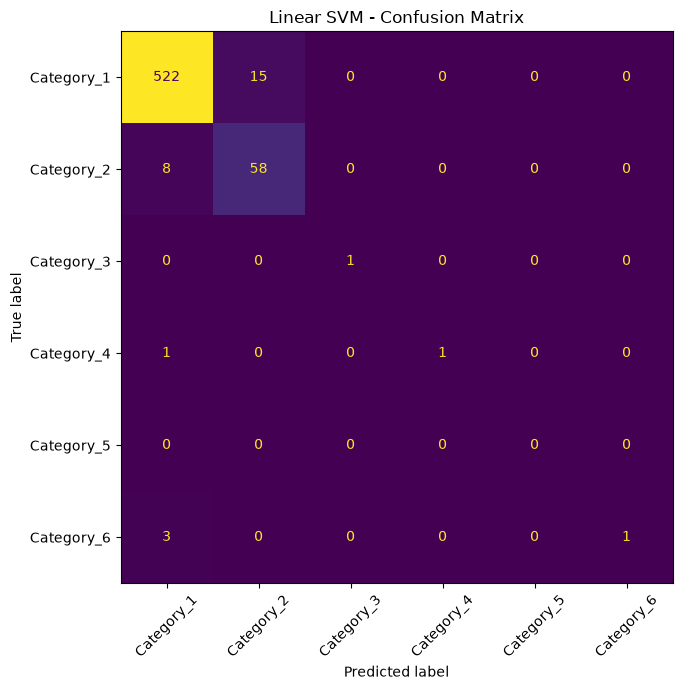

In [244]:
# Plot the Linear SVM confusion matrix
svm_cm = confusion_matrix(
    y_holdout,
    svm_pred,
    labels=baseline_model.classes_
)

svm_display = ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=baseline_model.classes_
)

fig, ax = plt.subplots(figsize=(9, 7))
svm_display.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Linear SVM - Confusion Matrix")
plt.tight_layout()
plt.show()

## 28. Validate Model Comparison Metrics

Recalculate accuracy, balanced accuracy, and macro F1 for both models using the same holdout labels and complete set of classes. 
This ensures that the model comparison is consistent before further tuning.

In [245]:
# Use the same class labels for both models
all_classes = baseline_model.classes_

# Recalculate metrics for Logistic Regression
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_holdout, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_holdout, y_pred),
    "Macro F1": f1_score(
        y_holdout, y_pred,
        labels=all_classes,
        average="macro",
        zero_division=0
    )
}

# Recalculate metrics for Linear SVM
svm_results = {
    "Model": "Linear SVM",
    "Accuracy": accuracy_score(y_holdout, svm_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_holdout, svm_pred),
    "Macro F1": f1_score(
        y_holdout, svm_pred,
        labels=all_classes,
        average="macro",
        zero_division=0
    )
}

# Display the corrected comparison
model_comparison = pd.DataFrame([
    logistic_results,
    svm_results
])

display(model_comparison.sort_values("Macro F1", ascending=False))

d:\EY_Data_Science_Challenge\venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,Model,Accuracy,Balanced Accuracy,Macro F1
0,Logistic Regression,0.940984,0.876706,0.703852
1,Linear SVM,0.955738,0.720171,0.645998


## 29. Hyperparameter Tuning

Tune Logistic Regression using cross-validation on the training set. Compare different regularization strengths and class-weight settings using macro F1-score.

The holdout set will not be used for hyperparameter selection.

In [246]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define the hyperparameters to test
param_grid = {
    "C": [0.1, 1, 10],
    "class_weight": ["balanced", None]
}

# Create the model
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Use 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Tune using training data only
grid_search.fit(X_train_transformed, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV Macro F1:", round(grid_search.best_score_, 4))

d:\EY_Data_Science_Challenge\venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'C': 10, 'class_weight': 'balanced'}
Best CV Macro F1: 0.7126


## 30. Evaluate the Tuned Logistic Regression Model

Evaluate the best Logistic Regression configuration selected through cross-validation. Compare its performance against the baseline using accuracy, balanced accuracy, macro F1-score, and per-class metrics.

The holdout set is used here for evaluation, not for further hyperparameter tuning.

In [247]:
# Get the best model selected during hyperparameter tuning
best_model = grid_search.best_estimator_

# Predict the holdout labels
tuned_pred = best_model.predict(X_holdout_transformed)

# Calculate evaluation metrics
tuned_accuracy = accuracy_score(y_holdout, tuned_pred)

tuned_balanced_accuracy = balanced_accuracy_score(
    y_holdout, tuned_pred
)

tuned_macro_f1 = f1_score(
    y_holdout,
    tuned_pred,
    labels=best_model.classes_,
    average="macro",
    zero_division=0
)

print("Tuned Logistic Regression Results")
print("---------------------------------")
print(f"Accuracy:          {tuned_accuracy:.4f}")
print(f"Balanced Accuracy: {tuned_balanced_accuracy:.4f}")
print(f"Macro F1-score:    {tuned_macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_holdout,
    tuned_pred,
    labels=best_model.classes_,
    zero_division=0
))

Tuned Logistic Regression Results
---------------------------------
Accuracy:          0.9541
Balanced Accuracy: 0.8744
Macro F1-score:    0.7439

Classification Report:
              precision    recall  f1-score   support

  Category_1       0.99      0.96      0.97       537
  Category_2       0.75      0.91      0.82        66
  Category_3       1.00      1.00      1.00         1
  Category_4       1.00      1.00      1.00         2
  Category_5       0.00      0.00      0.00         0
  Category_6       1.00      0.50      0.67         4

    accuracy                           0.95       610
   macro avg       0.79      0.73      0.74       610
weighted avg       0.96      0.95      0.96       610



d:\EY_Data_Science_Challenge\venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [248]:
# Compare baseline and tuned Logistic Regression
model_comparison = pd.DataFrame([
    {
        "Model": "Baseline Logistic Regression",
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "Macro F1": macro_f1
    },
    {
        "Model": "Tuned Logistic Regression",
        "Accuracy": tuned_accuracy,
        "Balanced Accuracy": tuned_balanced_accuracy,
        "Macro F1": tuned_macro_f1
    }
])

display(model_comparison)

,Model,Accuracy,Balanced Accuracy,Macro F1
0,Baseline Logistic Regression,0.940984,0.876706,0.703852
1,Tuned Logistic Regression,0.954098,0.874369,0.743856


In [249]:
# Generate the tuned model's classification report
print(classification_report(
    y_holdout,
    tuned_pred,
    labels=best_model.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

  Category_1       0.99      0.96      0.97       537
  Category_2       0.75      0.91      0.82        66
  Category_3       1.00      1.00      1.00         1
  Category_4       1.00      1.00      1.00         2
  Category_5       0.00      0.00      0.00         0
  Category_6       1.00      0.50      0.67         4

    accuracy                           0.95       610
   macro avg       0.79      0.73      0.74       610
weighted avg       0.96      0.95      0.96       610



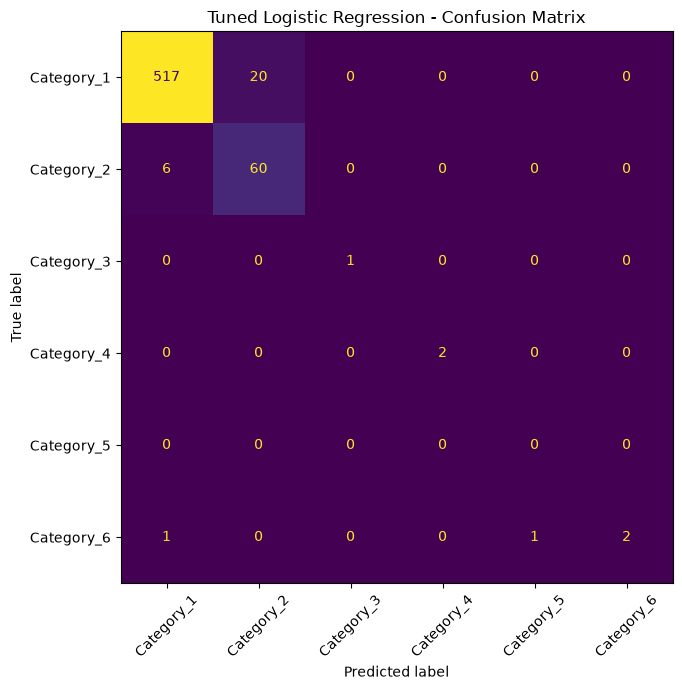

In [250]:
# Plot the tuned model's confusion matrix
tuned_cm = confusion_matrix(
    y_holdout,
    tuned_pred,
    labels=best_model.classes_
)

tuned_display = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm,
    display_labels=best_model.classes_
)

fig, ax = plt.subplots(figsize=(9, 7))
tuned_display.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

In [251]:
# Display the Category_5 records
category_5_rows = df_model[
    df_model["ClassificationLabel"] == "Category_5"
]

print("Category_5 record count:", len(category_5_rows))

display(category_5_rows[input_cols + ["ClassificationLabel"]])

# Check the number of unique input combinations
print(
    "Unique Category_5 input combinations:",
    category_5_rows[input_cols].drop_duplicates().shape[0]
)

Category_5 record count: 2


,Col1,Col2,Col3,Col4,Col5,Col6,Col7,ClassificationLabel
1645,Word324 Word4,18-8236-OMQ,-4645.86,Word694 Word695 Word160 Word817 Word1276 Word1...,2018-10-31,Word52 Word330 Word566,NoDoc,Category_5
2791,Word324 Word4,18-8154-OMV,-790.66,Word700 Word980 Word160 Word883 Word695 Word15...,2018-10-31,Word588 Word568 Word490,Doc1,Category_5


Unique Category_5 input combinations: 2


In [252]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


## 31. Compare Class Imbalance Strategies

Compare the baseline, tuned Logistic Regression and controlled random undersampling. Use the same holdout set and evaluation metrics to understand how each strategy affects classification performance.

In [ ]:
Import the undersampling method
from imblearn.under_sampling import RandomUnderSampler

# Reduce only Category_1 to 1,000 records
sampling_strategy = {
    "Category_1": 1000
}

undersampler = RandomUnderSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

# Apply undersampling to the training data only
X_train_under, y_train_under = undersampler.fit_resample(
    X_train_transformed,
    y_train
)

# Compare class distributions
print("Before undersampling:")
print(y_train.value_counts())

print("\nAfter undersampling:")
print(y_train_under.value_counts())

print("\nTraining shape before:", X_train_transformed.shape)
print("Training shape after:", X_train_under.shape)

Before undersampling:
ClassificationLabel
Category_1    4675
Category_2     563
Category_3      22
Category_4      14
Category_6       8
Category_5       2
Name: count, dtype: int64

After undersampling:
ClassificationLabel
Category_1    1000
Category_2     563
Category_3      22
Category_4      14
Category_6       8
Category_5       2
Name: count, dtype: int64

Training shape before: (5284, 2294)
Training shape after: (1609, 2294)


In [ ]:
# Train Logistic Regression on undersampled data
undersampled_model = LogisticRegression(
    C=10,
    class_weight=None,
    max_iter=2000,
    random_state=42
)

undersampled_model.fit(X_train_under, y_train_under)

# Predict on the unchanged holdout data
undersampled_pred = undersampled_model.predict(
    X_holdout_transformed
)

# Evaluate the model
print("Accuracy:",
      accuracy_score(y_holdout, undersampled_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_holdout, undersampled_pred))

print("Macro F1:",
      f1_score(
          y_holdout,
          undersampled_pred,
          labels=best_model.classes_,
          average="macro",
          zero_division=0
      ))

print("\nClassification Report:")
print(classification_report(
    y_holdout,
    undersampled_pred,
    labels=best_model.classes_,
    zero_division=0
))

Accuracy: 0.9393442622950819
Balanced Accuracy: 0.7217623158963942
Macro F1: 0.6361482471776588

Classification Report:
              precision    recall  f1-score   support

  Category_1       0.98      0.95      0.97       537
  Category_2       0.69      0.91      0.78        66
  Category_3       1.00      1.00      1.00         1
  Category_4       1.00      0.50      0.67         2
  Category_5       0.00      0.00      0.00         0
  Category_6       1.00      0.25      0.40         4

    accuracy                           0.94       610
   macro avg       0.78      0.60      0.64       610
weighted avg       0.95      0.94      0.94       610



d:\EY_Data_Science_Challenge\venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 32. Random Forest Model

Train a Random Forest classifier using the preprocessed training data. Use class weighting to account for target imbalance and evaluate the model on the original holdout set.

Compare its performance with Logistic Regression using accuracy, balanced accuracy, and macro F1-score.

In [258]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model on the original training data
rf_model.fit(X_train_transformed, y_train)

print("Random Forest trained successfully.")

# Predict the holdout labels
rf_pred = rf_model.predict(X_holdout_transformed)

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_holdout, rf_pred)

rf_balanced_accuracy = balanced_accuracy_score(
    y_holdout, rf_pred
)

rf_macro_f1 = f1_score(
    y_holdout,
    rf_pred,
    labels=best_model.classes_,
    average="macro",
    zero_division=0
)

print("\nRandom Forest Results")
print("---------------------")
print(f"Accuracy:          {rf_accuracy:.4f}")
print(f"Balanced Accuracy: {rf_balanced_accuracy:.4f}")
print(f"Macro F1:           {rf_macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_holdout,
    rf_pred,
    labels=best_model.classes_,
    zero_division=0
))

Random Forest trained successfully.

Random Forest Results
---------------------
Accuracy:          0.9492
Balanced Accuracy: 0.8263
Macro F1:           0.6973

Classification Report:
              precision    recall  f1-score   support

  Category_1       0.98      0.96      0.97       537
  Category_2       0.73      0.92      0.81        66
  Category_3       1.00      1.00      1.00         1
  Category_4       1.00      1.00      1.00         2
  Category_5       0.00      0.00      0.00         0
  Category_6       1.00      0.25      0.40         4

    accuracy                           0.95       610
   macro avg       0.79      0.69      0.70       610
weighted avg       0.96      0.95      0.95       610



In [260]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 2.1 MB/s eta 0:00:49
    --------------------------------------- 1.3/101.7 MB 2.6 MB/s eta 0:00:39
    --------------------------------------- 2.1/101.7 MB 3.1 MB/s eta 0:00:33
   - -------------------------------------- 3.1/101.7 MB 3.5 MB/s eta 0:00:29
   - -------------------------------------- 4.2/101.7 MB 3.9 MB/s eta 0:00:25
   -- ------------------------------------- 5.8/101.7 MB 4.5 MB/s eta 0:00:22
   --- ------------------------------------ 7.9/101.7 MB 5.3 MB/s eta 0:00:18
   ---- ----------------------------------- 10.5/101.7 MB 6.2 MB/s eta 0:00:15
   ----- ---------------------------------- 13.4/101.7 MB 7.0 MB/s eta 0:00:13
   ------- -------------------------------- 17.8/101.7 MB 8.6 MB/s eta 0:00:10
   -------- ------------------------------- 22.3/101.7 MB 9.8 MB/s eta 0:00

## 33. XGBoost Model

Train an XGBoost classifier to identify nonlinear patterns and interactions in the preprocessed features. 
Use balanced sample weights during training to account for class imbalance without generating synthetic records.

Evaluate predictions on the unchanged holdout set.

In [261]:
# Import XGBoost and the sample-weight utility
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder

# Encode target labels as integers
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

# Give more weight to records from minority classes
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# Create the XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# Train XGBoost on the original training data
xgb_model.fit(
    X_train_transformed,
    y_train_encoded,
    sample_weight=sample_weights
)

print("XGBoost trained successfully.")

# Predict the holdout data
xgb_pred_encoded = xgb_model.predict(X_holdout_transformed)

# Convert predictions back to the original class names
xgb_pred = label_encoder.inverse_transform(
    xgb_pred_encoded.astype(int)
)

# Calculate evaluation metrics
xgb_accuracy = accuracy_score(y_holdout, xgb_pred)

xgb_balanced_accuracy = balanced_accuracy_score(
    y_holdout, xgb_pred
)

xgb_macro_f1 = f1_score(
    y_holdout,
    xgb_pred,
    labels=best_model.classes_,
    average="macro",
    zero_division=0
)

print("\nXGBoost Results")
print("---------------")
print(f"Accuracy:          {xgb_accuracy:.4f}")
print(f"Balanced Accuracy: {xgb_balanced_accuracy:.4f}")
print(f"Macro F1:           {xgb_macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_holdout,
    xgb_pred,
    labels=best_model.classes_,
    zero_division=0
))

XGBoost trained successfully.

XGBoost Results
---------------
Accuracy:          0.9344
Balanced Accuracy: 0.7729
Macro F1:           0.6418

Classification Report:
              precision    recall  f1-score   support

  Category_1       0.99      0.94      0.96       537
  Category_2       0.67      0.92      0.78        66
  Category_3       1.00      1.00      1.00         1
  Category_4       1.00      0.50      0.67         2
  Category_5       0.00      0.00      0.00         0
  Category_6       0.40      0.50      0.44         4

    accuracy                           0.93       610
   macro avg       0.68      0.64      0.64       610
weighted avg       0.95      0.93      0.94       610



## 34. Comparison of result of all models

In [263]:

# Compare all selected models
all_model_results = [
    {
        "Model": "Tuned Logistic Regression",
        "Accuracy": tuned_accuracy,
        "Balanced Accuracy": tuned_balanced_accuracy,
        "Macro F1": tuned_macro_f1
    },
    {
        "Model": "Linear SVM",
        "Accuracy": svm_results["Accuracy"],
        "Balanced Accuracy": svm_results["Balanced Accuracy"],
        "Macro F1": svm_results["Macro F1"]
    },
    {
        "Model": "Controlled Undersampling",
        "Accuracy": accuracy_score(y_holdout, undersampled_pred),
        "Balanced Accuracy": balanced_accuracy_score(
            y_holdout, undersampled_pred
        ),
        "Macro F1": f1_score(
            y_holdout,
            undersampled_pred,
            labels=best_model.classes_,
            average="macro",
            zero_division=0
        )
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Balanced Accuracy": rf_balanced_accuracy,
        "Macro F1": rf_macro_f1
    },
    {
        "Model": "XGBoost",
        "Accuracy": xgb_accuracy,
        "Balanced Accuracy": xgb_balanced_accuracy,
        "Macro F1": xgb_macro_f1
    }
]

# Sort models by Macro F1
comparison_df = pd.DataFrame(all_model_results)

comparison_df = comparison_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

display(comparison_df.round(4))


d:\EY_Data_Science_Challenge\venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,Model,Accuracy,Balanced Accuracy,Macro F1
0,Tuned Logistic Regression,0.9541,0.8744,0.7439
1,Random Forest,0.9492,0.8263,0.6973
2,Linear SVM,0.9557,0.7202,0.6460
3,XGBoost,0.9344,0.7729,0.6418
4,Controlled Undersampling,0.9393,0.7218,0.6361


##  Model Selection Conclusion

Tuned Logistic Regression was selected as the current candidate model based on its balanced accuracy of 87.44% and Macro F1-score of 74.39%. Although Linear SVM achieved the highest accuracy of 95.57%, its balanced accuracy and Macro F1-score were lower.

Random Forest performed competitively but did not outperform tuned Logistic Regression on the selected metrics. XGBoost and controlled undersampling also produced lower Macro F1-scores.

The results suggest that tuned Logistic Regression is the most suitable candidate among the evaluated approaches for this dataset. However, the rare classes have very limited samples, so their performance requires cautious interpretation.

## Save the Final Model Pipeline

Save the fitted feature-preparation steps, preprocessing transformations, and tuned Logistic Regression model as a single pipeline.

This ensures that the same transformations are applied when new data is uploaded through the Streamlit dashboard. The holdout dataset will not be used to fit the pipeline.

In [271]:

# Import the required libraries
import joblib
from pathlib import Path
from sklearn.pipeline import Pipeline
from src.feature_preparation import FeaturePreparation

# Create the complete preprocessing and prediction pipeline
final_pipeline = Pipeline([
    ("feature_preparation", FeaturePreparation()),
    ("preprocessor", preprocessor),
    ("classifier", best_model)
])

# Train the pipeline using only the training data
final_pipeline.fit(X_train, y_train)

# Create the model folder if it does not exist
model_dir = Path("models")
model_dir.mkdir(parents=True, exist_ok=True)

# Save the trained pipeline
model_path = model_dir / "ey_classification_pipeline.joblib"
joblib.dump(final_pipeline, model_path)

print("Model pipeline saved successfully.")
print("Saved location:", model_path)


Model pipeline saved successfully.
Saved location: models\ey_classification_pipeline.joblib


In [275]:
from sklearn.pipeline import Pipeline

# Build the pipeline using the importable class
final_pipeline = Pipeline([
    ("feature_preparation", FeaturePreparation()),
    ("preprocessor", preprocessor),
    ("classifier", best_model)
])

# Fit using training data only
final_pipeline.fit(X_train, y_train)

# Save the pipeline to the models folder
model_path = (
    project_dir / "models" / "ey_classification_pipeline.joblib"
)

joblib.dump(final_pipeline, model_path)

print("Pipeline saved successfully:", model_path)

Pipeline saved successfully: D:\EY_Data_Science_Challenge\models\ey_classification_pipeline.joblib


## Verify the Saved Pipeline

Load the saved pipeline and compare its predictions with the tuned Logistic Regression model. This checks that the saved pipeline can process raw input features and reproduce the expected predictions.

In [273]:
# Load the saved pipeline
import joblib
import numpy as np

loaded_pipeline = joblib.load(model_path)

# Predict using the raw holdout data
saved_predictions = loaded_pipeline.predict(X_holdout)

# Compare predictions with the tuned model
print("Prediction count:", len(saved_predictions))

print(
    "Predictions match:",
    np.array_equal(saved_predictions, tuned_pred)
)

Prediction count: 610
Predictions match: True


In [276]:
# Load the newly saved pipeline
loaded_pipeline = joblib.load(model_path)

# Test it on the holdout features
saved_predictions = loaded_pipeline.predict(X_holdout)

print("Prediction count:", len(saved_predictions))
print(
    "Predictions match:",
    np.array_equal(saved_predictions, tuned_pred)
)

Prediction count: 610
Predictions match: True
